In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings # Ignores any warning
warnings.filterwarnings("ignore")

In [2]:
advt = pd.read_csv("https://raw.githubusercontent.com/dsrscientist/DSData/master/Advertising.csv")
advt.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
advt=advt.drop("Unnamed: 0",axis=1)

In [4]:
advt.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
advt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
advt.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


Describing the Aggregated Statistical Figures of Media Transactional and Sales Count

In [7]:
advt.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

No Null values present in the data set, Hence the data is clean

Outlier Analysis

Data Cleaning and Outlier Analysis

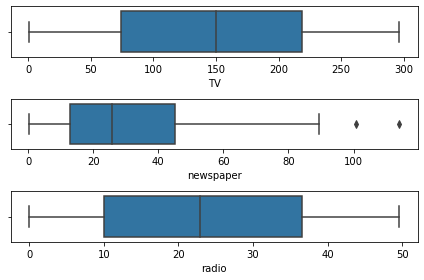

In [8]:
fig, axs = plt.subplots(3, figsize = (6,4))
plt1 = sns.boxplot(advt['TV'], ax =axs[0])
plt2 = sns.boxplot(advt['newspaper'], ax =axs[1])
plt3 = sns.boxplot(advt['radio'], ax =axs[2])
plt.tight_layout()

Univariate Analysis- Sales is the Target Variable

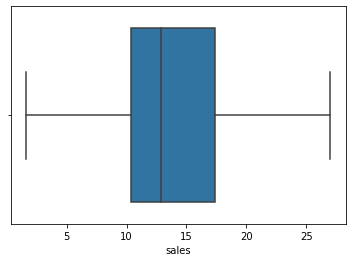

In [9]:
sns.boxplot(advt['sales'])
plt.show()

Seeing how Sales are related to other variables using scatter plot.

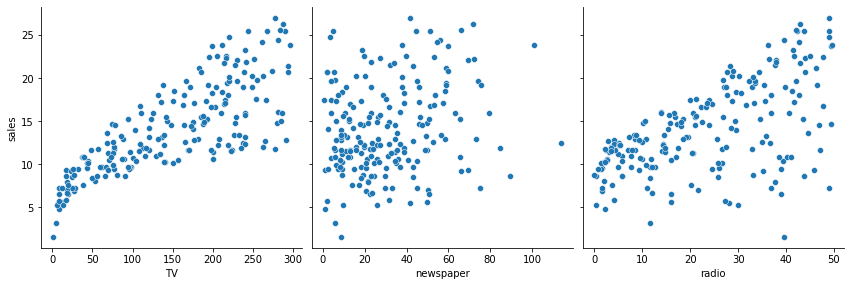

In [10]:
sns.pairplot(advt, x_vars=['TV', 'newspaper', 'radio'], y_vars = 'sales', height=4, aspect=1, kind='scatter')
plt.show()

It is appearing that TV data set seems to be more linear as compared to other variable dispersion of values, let us confirm it through observing correlation values by generating a heat map.

Checking the Correlation Between Different Variables

In [11]:
advt.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


Heatmap of the Correlation Between Different Variables

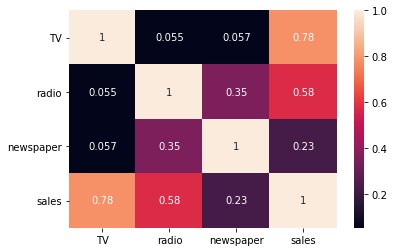

In [12]:
sns.heatmap(advt.corr(),annot=True)
plt.show()

As seem from the scatter plot and the heat map the Correlation factor for TV variable is 0.78, It means it is highly correlated with Sales. So now sales prediction is performed in TV as our feature variable.

Building Simple Linear Regression Model for the TV as a feature variable

In [13]:
X = advt.drop(['sales'],axis=1)
y = advt['sales']

Now the data is split for training and testing data sets, it is done by importing train_test_split. 70% of the data as training and 30% for testing.

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.7, test_size = 0.3, random_state = 100)

In [15]:
X_train.head()

,TV,radio,newspaper
74,213.4,24.6,13.1
3,151.5,41.3,58.5
185,205.0,45.1,19.6
26,142.9,29.3,12.6
90,134.3,4.9,9.3


In [16]:
y_train.head()

74     17.0
3      18.5
185    22.6
26     15.0
90     11.2
Name: sales, dtype: float64

# Building Linear Regression: Showing Traing Data

In [17]:
import statsmodels.api as sm

In [18]:
X_train_sm = sm.add_constant(X_train)

In [19]:
lnr = sm.OLS(y_train, X_train_sm).fit()

In [20]:
lnr.params

const        2.652790
TV           0.045426
radio        0.189758
newspaper    0.004603
dtype: float64

In [21]:
print(lnr.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     377.6
Date:                Sun, 27 Feb 2022   Prob (F-statistic):           9.97e-66
Time:                        21:45:01   Log-Likelihood:                -280.83
No. Observations:                 140   AIC:                             569.7
Df Residuals:                     136   BIC:                             581.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.6528      0.384      6.906      0.0

Building Linear Model: Importing statsmodels. API Library and Displaying Regression Results of OLS Model

Linear Regression Equation is: Sales=6.9847+0.0545*(TV or Newspaper or Radio) And Visualizing Fit on the Training Data

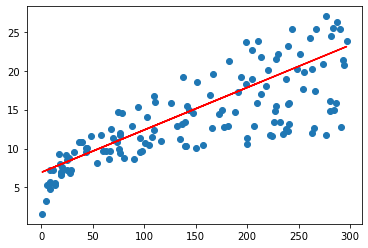

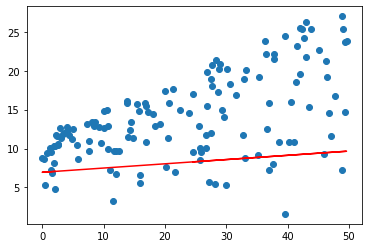

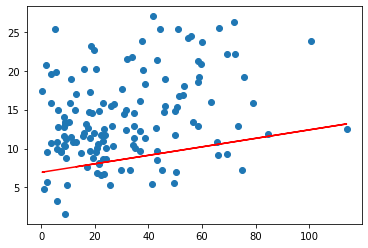

In [22]:
for i in X_train:
    plt.scatter(X_train[i], y_train)
    plt.plot(X_train[i], 6.9487 +0.0545*X_train[i], 'r')
    plt.show()

Residual Analysis and Distribution of Errors

In [23]:
y_train_pred = lnr.predict(X_train_sm)
resid = (y_train - y_train_pred)

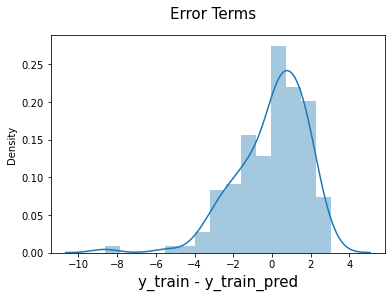

In [24]:
fig = plt.figure()
sns.distplot(resid, bins = 15)
fig.suptitle('Error Terms', fontsize=15)
plt.xlabel('y_train - y_train_pred', fontsize = 15)
plt.show()

Predictions on the Test data set

In [25]:
X_test_sm = sm.add_constant(X_test)
y_pred = lnr.predict(X_test_sm)

In [26]:
y_pred.head()

126    10.621601
104    20.006253
99     16.918509
92     19.170407
111    20.949741
dtype: float64

In [27]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [28]:
np.sqrt(mean_squared_error(y_test, y_pred))

1.3603977338130597

Checking the R-squared value on the test data

In [29]:
r_squared = r2_score(y_test, y_pred)

In [30]:
r_squared

0.9058622107532239

Visualizing the fit on the test data

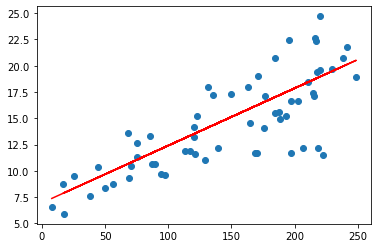

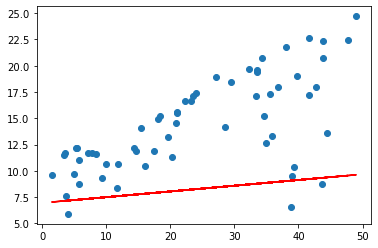

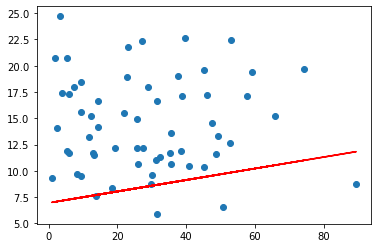

In [31]:
for i in X_test:
    plt.scatter(X_test[i], y_test)
    plt.plot(X_test[i], 6.9487 +0.0545*X_test[i], 'r')
    plt.show()